# Customer Churn Data Cleaning & EDA

In this notebook, we load the raw Indian Bank Customer Churn dataset, clean it (handling missing values, duplicates, and data type issues), and perform exploratory data analysis. We will also test a hypothesis regarding churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme(style="whitegrid")

## 1. Load Data
Let's load the data and check initial row counts.

In [2]:
df = pd.read_csv('../data/indian_bank_customer_churn.csv')
print(f"Initial Row Count: {len(df)}")
df.head()

Initial Row Count: 10050


,CustomerID,Gender,Location,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,10001,Male,Hyderabad,18.000000,1,"₹ 71,993.87",2,1,1,82042.759023,0
1,10002,M,Chennai,48.048275,2,"₹ 52,803.26",2,1,1,51977.220605,0
2,10003,Female,Delhi,NaN,9,₹ 0.00,1,1,1,64878.930001,0
3,10004,Female,Kolkata,59.352099,8,"₹ 59,252.24",2,0,0,80098.670584,1
4,10005,Male,Bangalore,63.327650,2,"₹ 59,554.13",2,1,1,NaN,0


## 2. Data Cleaning
### 2.1 Handle Duplicates

In [3]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()
print(f"Row count after dropping duplicates: {len(df)}")

Number of duplicate rows: 50
Row count after dropping duplicates: 10000


### 2.2 Fix Data Types
The `Balance` column has rupees formatting (e.g., '₹ 50,000.00'). We need to clean this to float.

In [4]:
if df['Balance'].dtype == 'object':
    df['Balance'] = df['Balance'].astype(str).str.replace('₹ ', '', regex=False).str.replace(',', '', regex=False)
    df['Balance'] = pd.to_numeric(df['Balance'], errors='coerce')
print("Balance dtype:", df['Balance'].dtype)

Balance dtype: float64


### 2.3 Handle Missing Values

In [5]:
print("Missing values before cleaning:\n", df.isnull().sum())

# Impute Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute EstimatedSalary with median
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(df['EstimatedSalary'].median())

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 CustomerID           0
Gender               0
Location             0
Age                150
Tenure               0
Balance              0
NumOfProducts        0
HasCreditCard        0
IsActiveMember       0
EstimatedSalary    200
Churn                0
dtype: int64

Missing values after cleaning:
 CustomerID         0
Gender             0
Location           0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCreditCard      0
IsActiveMember     0
EstimatedSalary    0
Churn              0
dtype: int64


### 2.4 Standardize Categorical Data

In [6]:
df['Gender'] = df['Gender'].replace({'M': 'Male', 'F': 'Female'})
df['Location'] = df['Location'].str.title() # fix 'mumbai' and 'DELHI'
print("Cleaned Locations:", df['Location'].unique())

Cleaned Locations: ['Hyderabad' 'Chennai' 'Delhi' 'Kolkata' 'Bangalore' 'Mumbai' 'Pune']


### Save Cleaned Dataset

In [7]:
df.to_csv('../data/cleaned_indian_bank_churn.csv', index=False)
print(f"Final Cleaned Dataset Row Count: {len(df)}")

Final Cleaned Dataset Row Count: 10000


## 3. Exploratory Data Analysis
### 3.1 Overall Churn Rate

Overall Churn Rate: 16.53%


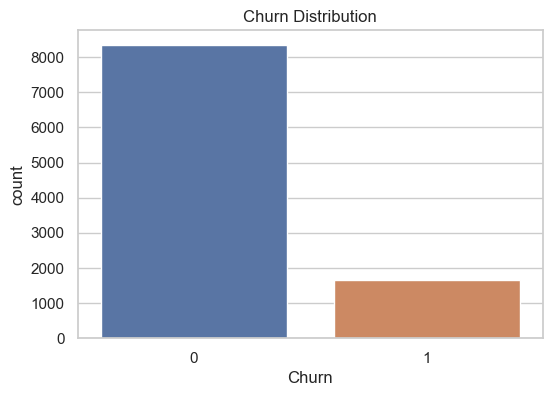

In [8]:
churn_rate = df['Churn'].mean()
print(f"Overall Churn Rate: {churn_rate:.2%}")

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

### 3.2 Churn by Demographic Segments

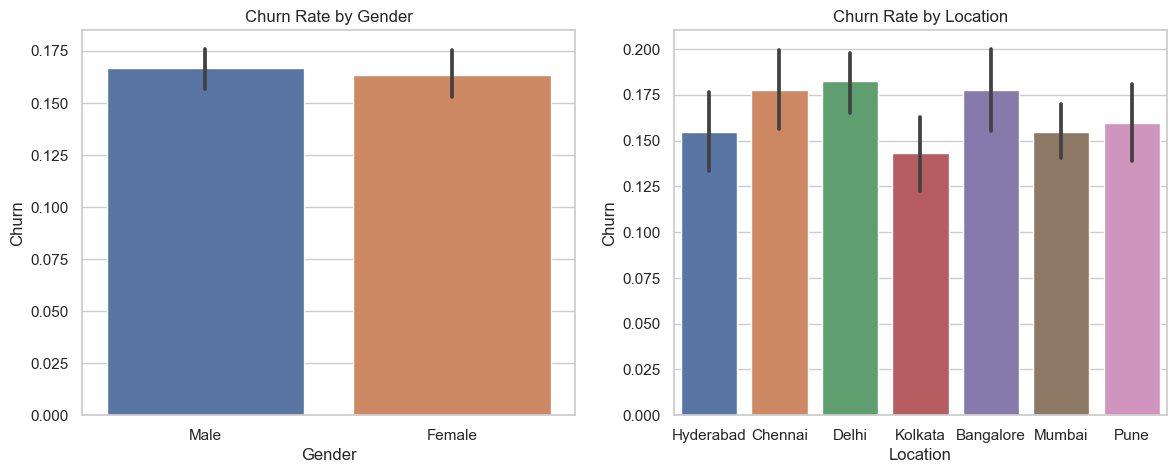

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='Gender', y='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn Rate by Gender')

sns.barplot(x='Location', y='Churn', data=df, ax=axes[1])
axes[1].set_title('Churn Rate by Location')
plt.show()

### 3.3 Churn by Engagement (Tenure & Num of Products)

C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\KHUSHI\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


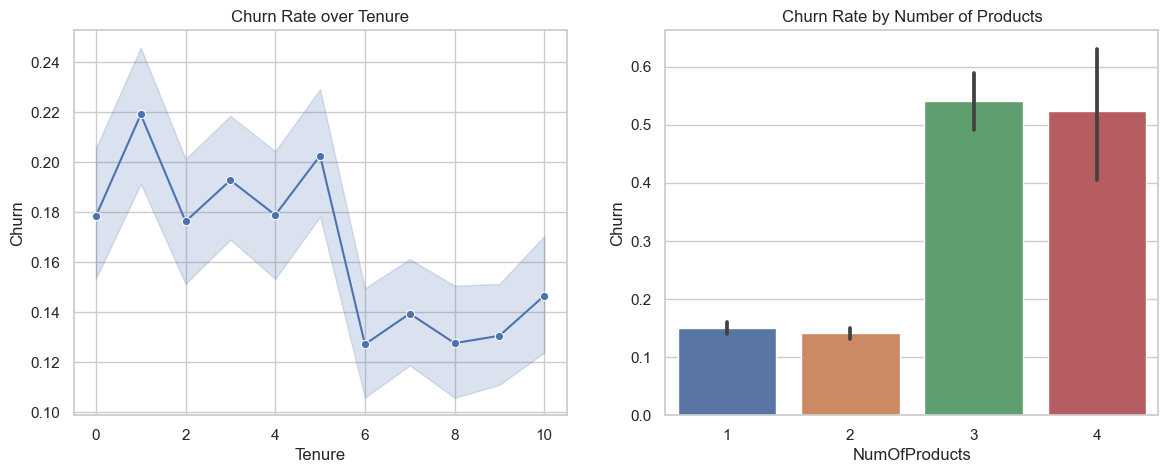

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(x='Tenure', y='Churn', data=df, marker='o', ax=axes[0])
axes[0].set_title('Churn Rate over Tenure')

sns.barplot(x='NumOfProducts', y='Churn', data=df, ax=axes[1])
axes[1].set_title('Churn Rate by Number of Products')
plt.show()

### 3.4 Churn vs Continuous Variables (Balance & Age)

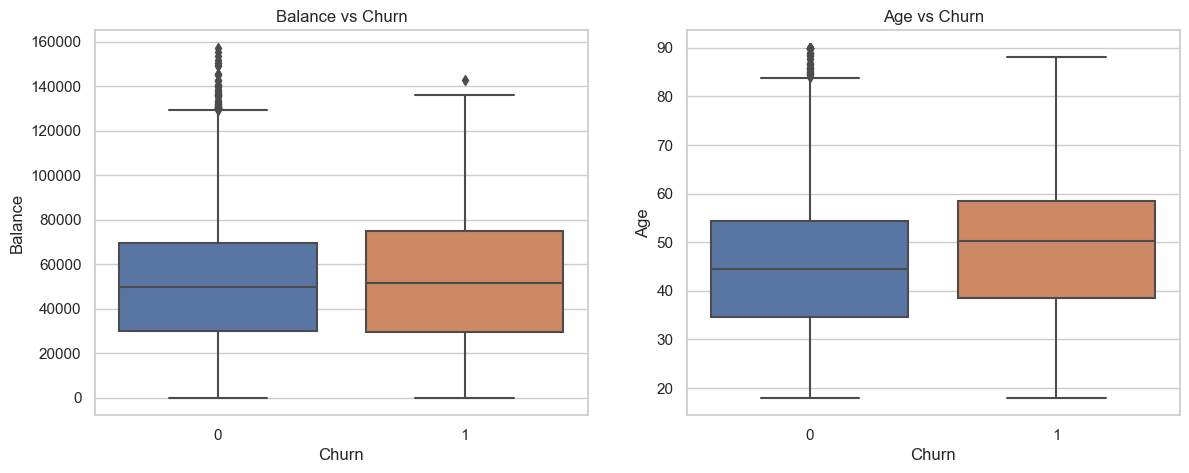

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Churn', y='Balance', data=df, ax=axes[0])
axes[0].set_title('Balance vs Churn')

sns.boxplot(x='Churn', y='Age', data=df, ax=axes[1])
axes[1].set_title('Age vs Churn')
plt.show()

## 4. Hypothesis Testing
**Hypothesis**: Older customers (Age > 50) have a different churn rate compared to younger customers.
- H0: The churn rate for customers >50 and <=50 is the same.
- H1: The churn rates are significantly different.
We will use a Chi-Square test of independence.

In [12]:
df['AgeGroup'] = np.where(df['Age'] > 50, '>50', '<=50')
contingency_table = pd.crosstab(df['AgeGroup'], df['Churn'])
print("Contingency Table:\n", contingency_table)

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in churn rates between age groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

Contingency Table:
 Churn        0    1
AgeGroup           
<=50      5496  803
>50       2851  850

Chi-Square Statistic: 175.6931
P-value: 4.2253e-40
Conclusion: Reject the null hypothesis. There is a significant difference in churn rates between age groups.
